# 06 · Restatements: which numbers changed, and how it was disclosed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/06_restatements.ipynb)

**What you will learn**

- How to read `restatement_events`: one row per reported number that a later SEC filing changed,
  with the original value, the current value and both filings.
- What the three `disclosure_class` values assert, and what they do not.
- How to check any revision yourself on sec.gov in two clicks.
- How the `fact` table carries the as-filed and current value of every number.

**Plan required:** none. The restatement feed is available on every plan, including the free
sample with no API key, and it is not narrowed to your plan's universe: it covers every
company with a revision.

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. One row per changed number

A company restates when a later filing reports a different value for a period it already
reported. Each row of `restatement_events` is one such change: `first_value` (as first filed,
in `first_accession`) and `current_value` (the latest, in `current_accession`), the size of the
change (`delta_abs`, and `delta_pct` as a fraction: `-0.10` is -10%), and how it reached the
public:

| `disclosure_class` | Meaning |
|---|---|
| `non_reliance` | The company filed an 8-K Item 4.02 telling investors not to rely on the earlier financial statements. Read from the actual 8-K, never inferred. |
| `amended` | The new value arrived in an amended report (10-K/A or 10-Q/A). |
| `undisclosed` | The value changed inside a routine 10-K or 10-Q, with no Item 4.02 and no amendment. |

The class describes the disclosure mechanics only. It says nothing about intent: adopting a new
accounting standard, for example, legitimately restates prior-year comparatives.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()

mix = client.run_query("""
    SELECT disclosure_class, count(*) AS revisions, count(DISTINCT cik) AS companies
    FROM restatement_events
    GROUP BY disclosure_class
    ORDER BY revisions DESC
""")
mix["share_of_revisions"] = (mix["revisions"] / mix["revisions"].sum()).map("{:.1%}".format)
mix


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


,disclosure_class,revisions,companies,share_of_revisions
0,undisclosed,76383,9707,84.8%
1,non_reliance,8377,1352,9.3%
2,amended,5354,1489,5.9%


## 2. One revision, end to end

`client.restatements()` filters the feed by company, class and severity. Monolithic Power
Systems (MPWR) restated its fiscal 2024 net income after an Item 4.02 notice.

In [3]:
mpwr = client.restatements(ticker="MPWR", limit=500)
event = mpwr[(mpwr["standard_concept"] == "NetIncome") & (mpwr["period_end"] == pd.Timestamp("2024-12-31"))]
event[["ticker", "standard_concept", "period_end", "first_value", "current_value", "delta_pct",
       "disclosure_class", "first_accession", "current_accession", "restated_in_form"]]

,ticker,standard_concept,period_end,first_value,current_value,delta_pct,disclosure_class,first_accession,current_accession,restated_in_form
5,MPWR,NetIncome,2024-12-31,1.786700e+09,1.592058e+09,-0.108939,non_reliance,0001437749-25-005903,0001437749-26-006113,10-K


Every accession number maps to a folder on sec.gov. Open both and compare the figure yourself;
you do not need to trust us.

In [4]:
def sec_folder(cik: str, accession: str) -> str:
    """URL of the EDGAR folder that holds every document of one filing."""
    return f"https://www.sec.gov/Archives/edgar/data/{int(cik)}/{accession.replace('-', '')}/"

row = event.iloc[0]
print("as first filed :", sec_folder(row["cik"], row["first_accession"]) + str(row["first_primary_doc"]))
print("as restated    :", sec_folder(row["cik"], row["current_accession"]) + str(row["current_primary_doc"]))

as first filed : https://www.sec.gov/Archives/edgar/data/1280452/000143774925005903/mpwr20241231_10k.htm
as restated    : https://www.sec.gov/Archives/edgar/data/1280452/000143774926006113/mpwr20251231_10k.htm


## 3. Recent material revisions announced with an Item 4.02

`delta_pct` is a fraction, so a 10% threshold is `0.10`. A handful of rows are scale artifacts
(the same figure re-tagged in thousands instead of units shows up as a change near -100% or
several hundred times larger), so bound the size when you rank.

In [5]:
non_reliance = client.restatements(disclosure_class="non_reliance", limit=20000)
material = non_reliance[
    non_reliance["standard_concept"].isin(["NetIncome", "TotalRevenue", "OperatingIncome"])
    & (non_reliance["unit"] == "USD")
    & non_reliance["delta_pct"].abs().between(0.10, 0.90)
    & (non_reliance["last_filed_at"] >= pd.Timestamp("2023-01-01", tz="UTC"))
]
material[["ticker", "standard_concept", "period_end", "first_value", "current_value", "delta_pct",
          "last_filed_at"]].head(10)

,ticker,standard_concept,period_end,first_value,current_value,delta_pct,last_filed_at
7,EONR,NetIncome,2024-12-31,-9080283.0,-8128679.0,0.104799,2026-09-28 08:25:27-04:00
13,BURU,NetIncome,2026-06-30,-6475862.0,-5714861.0,0.117513,2026-09-21 18:08:38-04:00
16,BURU,NetIncome,2025-03-31,-14020050.0,-16611425.0,-0.184834,2026-09-21 18:08:38-04:00
20,BNC,NetIncome,2025-07-31,-5848397.0,-1186000.0,0.797209,2026-09-11 20:01:15-04:00
21,PAXH,OperatingIncome,2025-08-31,-875203.0,-576134.0,0.341714,2026-09-11 15:29:28-04:00
24,PAXH,NetIncome,2025-08-31,-875134.0,-745208.0,0.148464,2026-09-11 15:29:28-04:00
25,BWMG,NetIncome,2026-06-30,580542.0,218658.0,-0.623355,2026-09-10 14:40:14-04:00
26,BWMG,TotalRevenue,2026-06-30,1974245.0,2377891.0,0.204456,2026-09-10 14:40:14-04:00
32,LRHC,TotalRevenue,2025-06-30,23214218.0,20232097.0,-0.128461,2026-08-21 20:02:11-04:00
36,SLSN,NetIncome,2026-03-31,-766000.0,-962000.0,-0.255875,2026-08-19 21:03:16-04:00


## 4. How revisions reach the public, year by year

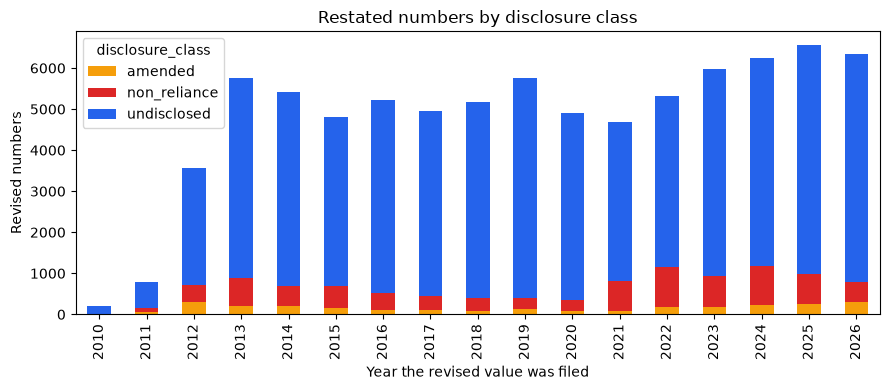

In [6]:
by_year = client.run_query("""
    SELECT year(last_filed_at) AS year, disclosure_class, count(*) AS revisions
    FROM restatement_events
    WHERE last_filed_at >= TIMESTAMP '2010-01-01'
    GROUP BY ALL
""").pivot(index="year", columns="disclosure_class", values="revisions").fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
by_year.plot.bar(stacked=True, ax=ax, color={"non_reliance": "#dc2626", "amended": "#f59e0b",
                                             "undisclosed": "#2563eb"})
ax.set_xlabel("Year the revised value was filed")
ax.set_ylabel("Revised numbers")
ax.set_title("Restated numbers by disclosure class")
plt.tight_layout()
plt.show()

## 5. The same history inside `fact`

Every `fact` row also carries `value_as_filed` (the first value reported for that number),
`value_current` (the latest) and `restated`. Two cautions:

- These columns are computed on today's data, not as of your `as_of`. They tell you what
  happened later; a backtest must not use them as a signal. For point-in-time values, pick the
  row by `accepted_at` (notebook 02).
- `restatement_events` is a public diff feed and is not filtered by `as_of`. A revision becomes
  known at its `last_filed_at`.

In [7]:
facts = client.read_table("fact", tickers="MPWR")
facts[
    (facts["standard_concept"] == "NetIncome")
    & (facts["fiscal_period"] == "FY")
    & (facts["period_end"] == pd.Timestamp("2024-12-31"))
][["accession_id", "accepted_at", "numeric_value", "value_as_filed", "value_current", "restated"]]

,accession_id,accepted_at,numeric_value,value_as_filed,value_current,restated
4773,0001437749-25-005903,2025-03-03 15:14:51-05:00,1.786700e+09,1.786700e+09,1.592058e+09,True
4789,0001437749-26-006113,2026-02-27 16:33:25-05:00,1.592058e+09,1.786700e+09,1.592058e+09,True


In [8]:
client.close()

## Next steps

- **[07 · Smart money](07_smart_money.ipynb)**: insider trades and 13F holdings (Institutional).
- **[14 · Restatement alpha](14_restatement_alpha.ipynb)**: what happened to the share price
  after a restatement.
- Script version: [`python/restatement_radar.py`](../python/restatement_radar.py).